# **Hoja de trabajo #2**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Mónica Salvatierra - 22249

Link del repositorio: https://github.com/paulabaal12/HT2-VPC

## **Task 4 - Implementación Práctica**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
def manual_convolution(image, kernel, stride=1, padding=0):

    H, W = image.shape
    F = kernel.shape[0]

    # P filas y columnas de ceros alrededor
    if padding > 0:
        padded_image = np.pad(image,
                              pad_width=((padding, padding), (padding, padding)),
                              mode="constant",
                              constant_values=0)
    else:
        padded_image = image

    H_p, W_p = padded_image.shape

    #    O = (W - F + 2P) / S + 1  
    out_h = int((H_p - F) / stride) + 1
    out_w = int((W_p - F) / stride) + 1

    #feature map de salida
    output = np.zeros((out_h, out_w), dtype=np.float32)

    # aplicación del producto punto local
    for i in range(out_h):
        for j in range(out_w):
            # Coordenadas de la región de la imagen donde aplicar el kernel
            start_i = i * stride
            start_j = j * stride

            # Extraemos el patch de tamaño F x F
            patch = padded_image[start_i:start_i + F, start_j:start_j + F]

            # Producto punto elemento a elemento y suma
            value = np.sum(patch * kernel)
            output[i, j] = value

    return output


Tamaño imagen pequeña: (5, 5)
Tamaño feature map (S=1, P=1): (5, 5)


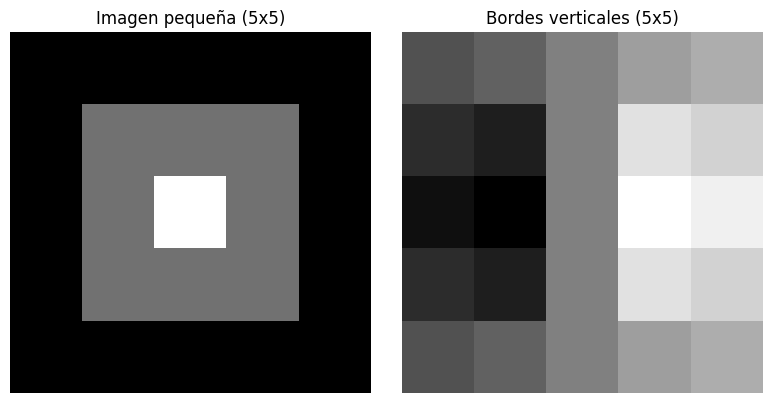

In [3]:
# imagen pequeña sintética (5x5)

small_image = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50,100, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
], dtype=np.float32)

# Filtro de borde vertical simple (similar al de la diapositiva)
vertical_edge_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)

small_feature_map = manual_convolution(small_image, vertical_edge_kernel,
                                      stride=1,
                                      padding=1)

print("Tamaño imagen pequeña:", small_image.shape)
print("Tamaño feature map (S=1, P=1):", small_feature_map.shape)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title('Imagen pequeña (5x5)')
plt.imshow(small_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Bordes verticales (5x5)')
plt.imshow(small_feature_map, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


Tamaño imagen original: (960, 1280)
Tamaño feature map (S=1, P=1): (960, 1280)


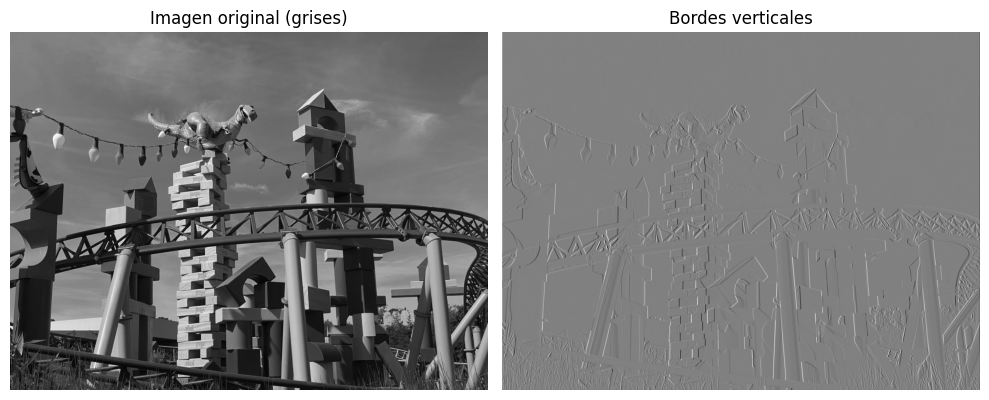

In [5]:
# Prueba con una imagen 
img_color = mpimg.imread('img/task4.jpeg')

# Convertir a escala de grises si es RGB
if img_color.ndim == 3:
    image_gray = 0.299 * img_color[..., 0] + 0.587 * img_color[..., 1] + 0.114 * img_color[..., 2]
else:
    image_gray = img_color.astype(float)

print("Tamaño imagen original:", image_gray.shape)

#  bordes verticales (Sobel en X)
sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# aplicación de  convolución manual
result_real = manual_convolution(image_gray, sobel_vertical,
                                 stride=1,
                                 padding=1)

print("Tamaño feature map (S=1, P=1):", result_real.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title('Imagen original (grises)')
plt.imshow(image_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Bordes verticales')
plt.imshow(result_real, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()